<a href="https://colab.research.google.com/github/Melchizedek-Madaki/codealpha_tasks/blob/main/Codealpha_CreditScoring/Predicting_Creditworthiness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub as kh
import pandas as pd
import numpy as np


In [ ]:
data_path = kh.dataset_download('bbjadeja/predicting-creditworthiness')

Using Colab cache for faster access to the 'predicting-creditworthiness' dataset.


In [ ]:
df = pd.read_excel(data_path + '/CreditWorthiness.xlsx')

**The dataset contains information on various attributes of loan applicants, including:**

- Cbal: Checking account balance
- Cdur: Credit duration
- Chist: Credit history
- Cpur: Purpose of the loan
- Camt: Loan amount
- Sbal: Savings account balance
- Edur: Employment duration
- InRate: Installment rate
- MSG: Marital status and gender
- Oparties: Other parties involved
- Rdur: Residence duration
- Prop: Property type
- Age: Applicant's age
- inPlans: Existing plans
- Htype: Housing type
- NumCred: Number of existing credits
- JobType: Job type
- Ndepend: Number of dependents
- telephone: Presence of a telephone
- foreign: Foreign worker status
- creditScore: Credit score

##**EDA (Exploratory Data Analysis)**

In [ ]:
!pip install skimpy

In [ ]:
from skimpy import skim

In [ ]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1000   │ │ string      │ 15    │                                                          │
│ │ Number of columns │ 21     │ │ int64       │ 6     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column     ┃ NA   ┃ NA %   ┃ mean    ┃ sd       ┃ p0     ┃ p25     ┃ p50     ┃ p75     ┃ p100    ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━┩  │
│ │    Cdur    │    0 │      0 │    20.9 │    12.06 │      4 │      12 │      18 │      24 │      72 │  █▆▃▁   │  │
│ │    Camt    │    0 │      0 │   32590 │    28230 │   2380 │   13540 │   23080 │   39600 │  184100 │   █▃▁   │  │
│ │   InRate   │    0 │      0 │   2.973 │    1.119 │      1 │       2 │       3 │       4 │       4 │ ▂ ▄ ▃█  │  │
│ │    age     │    0 │      0 │   35.55 │    11.38 │     19 │      27 │      33 │      42 │      75 │  ██▄▂▁  │  │
│ │  NumCred   │    0 │      0 │   1.407 │   0.5777 │      1 │       1 │       1 │       2 │       4 │   █ ▄   │  │
│ │  Ndepend   │    0 │      0 │   1.155 │   0.3621 │      1 │       1 │       1 │       1 │       2 │ █    ▁  │  │
│ └────────────┴──────┴────────┴─────────┴──────────┴────────┴─────────┴─────────┴─────────┴─────────┴─────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃           ┃           ┃           ┃           ┃ chars per ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest  ┃ longest   ┃ min       ┃ max       ┃ row       ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │   Cbal    │  0 │    0 │  Rs. < 0  │    no     │  Rs. < 0  │    no     │      14.3 │       3.7 │       3749 │  │
│ │           │    │      │           │ checking  │           │ checking  │           │           │            │  │
│ │           │    │      │           │  account  │           │  account  │           │           │            │  │
│ │   Chist   │  0 │    0 │    all    │   none    │    all    │   none    │      19.9 │       3.9 │       3862 │  │
│ │           │    │      │  settled  │ taken/all │  settled  │ taken/all │           │           │            │  │
│ │           │    │      │           │  settled  │           │  settled  │           │           │            │  │
│ │   Cpur    │  0 │    0 │ Business  │  second   │ Business  │  second   │      12.1 │       1.6 │       1583 │  │
│ │           │    │      │           │   hand    │           │   hand    │           │           │            │  │
│ │           │    │      │           │  vehicle  │           │  vehicle  │           │           │            │  │
│ │   Sbal    │  0 │    0 │   Rs. <   │  5000 <=  │  1000 <=  │    no     │      13.2 │       3.3 │       3332 │  │
│ │           │    │      │   1000    │   Rs. <   │   Rs

In [ ]:
df.isnull().sum()

Cbal           0
Cdur           0
Chist          0
Cpur           0
Camt           0
Sbal           0
Edur           0
InRate         0
MSG            0
Oparties       0
Rdur           0
Prop           0
age            0
inPlans        0
Htype          0
NumCred        0
JobType        0
Ndepend        0
telephone      0
foreign        0
creditScore    0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df

,Cbal,Cdur,Chist,Cpur,Camt,Sbal,Edur,InRate,MSG,Oparties,...,Prop,age,inPlans,Htype,NumCred,JobType,Ndepend,telephone,foreign,creditScore
0,0 <= Rs. < 2000,9,all settled till now,Business,13790,Rs. < 1000,1 to 4 years,2,married or widowed male,no one,...,real estate,27,bank,own,1,employee with official position,1,yes,no,good
1,0 <= Rs. < 2000,15,dues not paid earlier,electronics,15250,no savings account,more than 7 years,4,single male,"yes, guarantor",...,real estate,50,none,own,2,employee with official position,1,yes,no,good
2,0 <= Rs. < 2000,36,none taken/all settled,Business,19410,Rs. < 1000,more than 7 years,4,single male,no one,...,Unknown,61,none,free,1,"employed either in management, self or in high...",1,yes,no,bad
3,0 <= Rs. < 2000,48,none taken/all settled,Business,144090,Rs. < 1000,1 to 4 years,2,single male,no one,...,Other cars etc.,25,none,own,1,employee with official position,1,yes,no,bad
4,no checking account,24,all settled till now,electronics,31690,Rs. < 1000,less than 1 year,4,divorced or separated or married female,no one,...,life insurance/building society,26,none,own,1,employee with official position,1,yes,no,good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking account,6,all settled,second hand vehicle,7710,no savings account,1 to 4 years,1,single male,"yes, guarantor",...,real estate,26,stores,own,1,resident unskilled,2,no,no,good
996,0 <= Rs. < 2000,12,all settled till now,electronics,64560,no savings account,not employed,2,single male,no one,...,Unknown,52,none,own,1,"employed either in management, self or in high...",1,yes,no,bad
997,no checking account,36,dues not paid earlier,electronics,95540,Rs. < 1000,1 to 4 years,2,divorced or separated or married female,no one,...,Other cars etc.,31,stores,own,2,employee with official position,1,no,no,good
998,Rs. >=2000,18,all settled till now,second hand vehicle,19490,Rs. < 1000,more than 7 years,3,divorced or separated or married female,no one,...,Other cars etc.,23,none,own,1,"employed either in management, self or in high...",1,no,no,good


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Cbal         1000 non-null   str  
 1   Cdur         1000 non-null   int64
 2   Chist        1000 non-null   str  
 3   Cpur         1000 non-null   str  
 4   Camt         1000 non-null   int64
 5   Sbal         1000 non-null   str  
 6   Edur         1000 non-null   str  
 7   InRate       1000 non-null   int64
 8   MSG          1000 non-null   str  
 9   Oparties     1000 non-null   str  
 10  Rdur         1000 non-null   str  
 11  Prop         1000 non-null   str  
 12  age          1000 non-null   int64
 13  inPlans      1000 non-null   str  
 14  Htype        1000 non-null   str  
 15  NumCred      1000 non-null   int64
 16  JobType      1000 non-null   str  
 17  Ndepend      1000 non-null   int64
 18  telephone    1000 non-null   str  
 19  foreign      1000 non-null   str  
 20  creditScore  1000 no

In [ ]:
df = df.rename(columns={'creditScore': 'Credit Score'})

In [ ]:
df['Credit Score'].value_counts()

Credit Score
good    700
bad     300
Name: count, dtype: int64

##**Class Imbalance Overview**

The target variable `Credit Score` has a 70/30 split: 700 "good" cases vs. 300 "bad" cases. This is a moderate imbalance — not extreme (like 99/1 fraud detection), but enough to matter.

**Why it matters:**
A model can achieve 70% accuracy by always predicting "good" without learning any real pattern. This is called the accuracy paradox — the metric looks fine, but the model is useless. It never correctly identifies a single bad-credit applicant.

**Why it's worse here than in a "neutral" imbalanced problem:**
Standard classifiers trained on imbalanced data tend to be biased toward the majority class, because minimizing overall error naturally favors getting the common case right more often. In this dataset, "good" is the majority class — so the model's natural bias already points in the wrong direction relative to the cost matrix, where missing a "bad" case `(false negative)` costs 5x more than misclassifying a "good" one `(false positive)`. Imbalance and cost asymmetry compound each other here instead of canceling out.


In [ ]:
df.corr(numeric_only=True)

,Cdur,Camt,InRate,age,NumCred,Ndepend
Cdur,1.000000,0.624984,0.074749,-0.036136,-0.011284,-0.023834
Camt,0.624984,1.000000,-0.271316,0.032716,0.020795,0.017142
InRate,0.074749,-0.271316,1.000000,0.058266,0.021669,-0.071207
age,-0.036136,0.032716,0.058266,1.000000,0.149254,0.118201
NumCred,-0.011284,0.020795,0.021669,0.149254,1.000000,0.109667
Ndepend,-0.023834,0.017142,-0.071207,0.118201,0.109667,1.000000


##**Univariate Exploration: Single numeric features**

*Univariate analysis examines one single variable at a time*

In [ ]:
df.describe()

,Cdur,Camt,InRate,age,NumCred,Ndepend
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,32592.58000,2.973000,35.546000,1.407000,1.155000
std,12.058814,28227.36876,1.118715,11.375469,0.577654,0.362086
min,4.000000,2380.00000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,13535.00000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,23075.00000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,39602.50000,4.000000,42.000000,2.000000,1.000000
max,72.000000,184120.00000,4.000000,75.000000,4.000000,2.000000


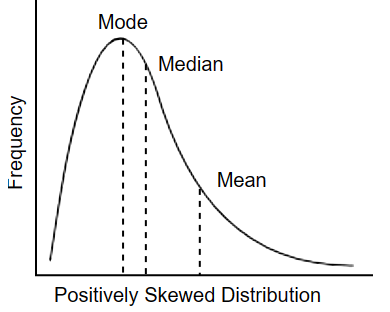

This dataset is righ-skewed for `cmat (loan amount)` - Compare mean `(32,593)` to median `(23,075)`. The mean is noticeably higher than the median. That only happens when there's a small number of very large values pulling the average up — picture a few loans around 150,000–184,000 dragging the mean upward, while most people's loans sit closer to the 13,000–39,000 range. If the data were symmetric, mean and median would be close together.

And the outlier signal: look at the gap between 75% `(39,602)` and max `(184,120)` — that's a huge jump compared to the gap between 25% and 75%. That tells you the max isn't just "a bit higher," it's way out on its own, off in the tail.

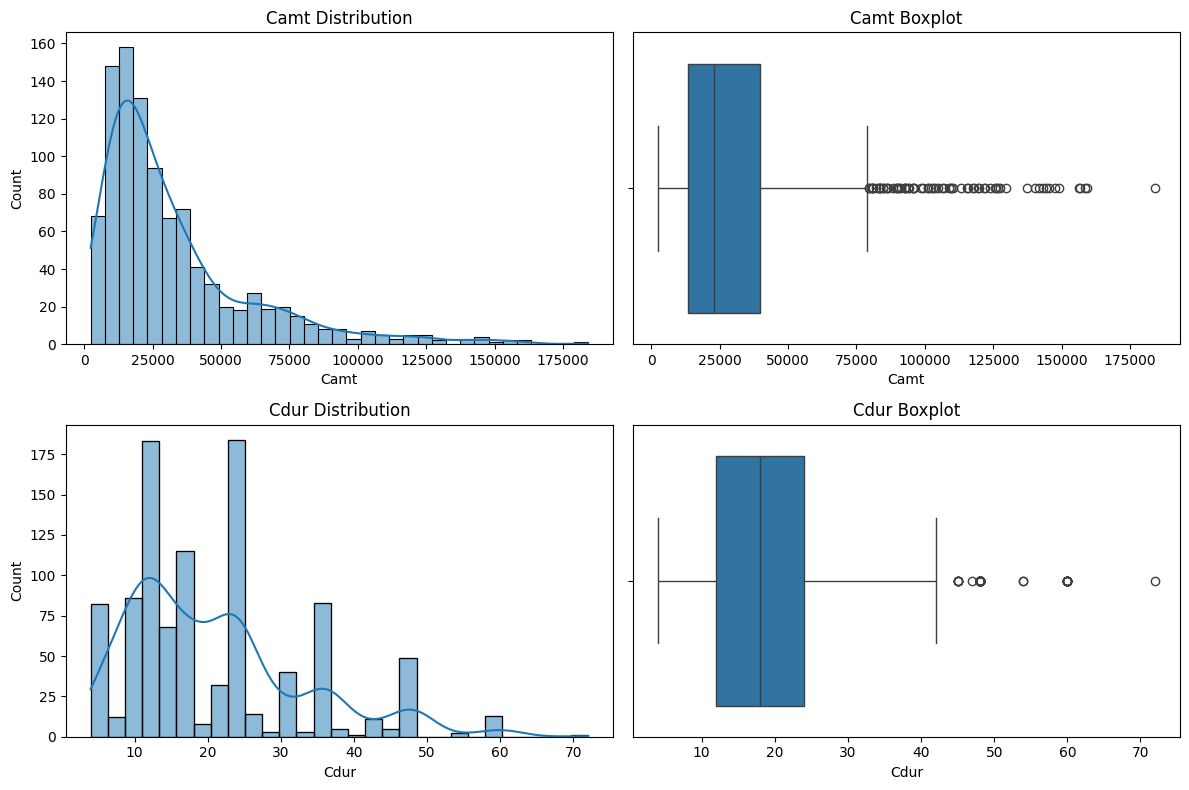

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) # 2 rows and 2 columns

sns.histplot(df['Camt'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Camt Distribution')

sns.boxplot(x=df['Camt'], ax=axes[0, 1])
axes[0, 1].set_title('Camt Boxplot')

sns.histplot(df['Cdur'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Cdur Distribution')

sns.boxplot(x=df['Cdur'], ax=axes[1, 1])
axes[1, 1].set_title('Cdur Boxplot')

plt.tight_layout()
plt.show()

From the plots above the whiskers extend to what's considered "normal" range, and every individual dot beyond the whisker is a statistical outlier, we can deduce for both features that:

- **Camt(Loan Amount):** The feature is righ-skewed cause, Most applicants borrow modest amounts, and a shrinking number borrow progressively more.

- **Cdur(Credit Duration):** Credit duration is the intemittent time duration given to a loaner before his due date, which from the distribution it shows that people who take (1-year, 2-year, 3-year loans) are clustered in the Interquartile Range(IQR), while the rest are less distributed

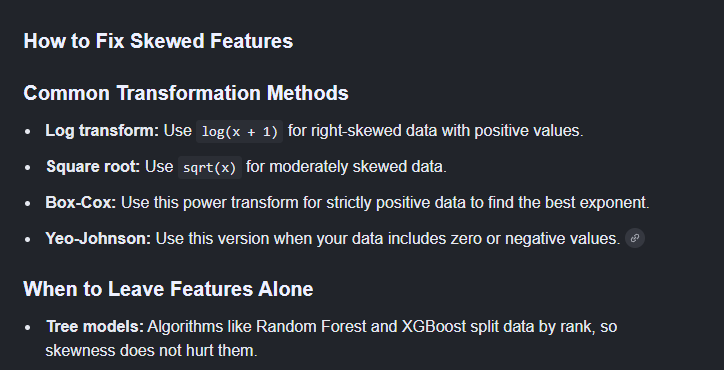

**For this particular skewed feature, we will use `Log Transform` cause it is tailored to our current situation**

In [ ]:
df['Camt_log'] = np.log(df['Camt'])
df['Cdur_log'] = np.log(df['Cdur'])

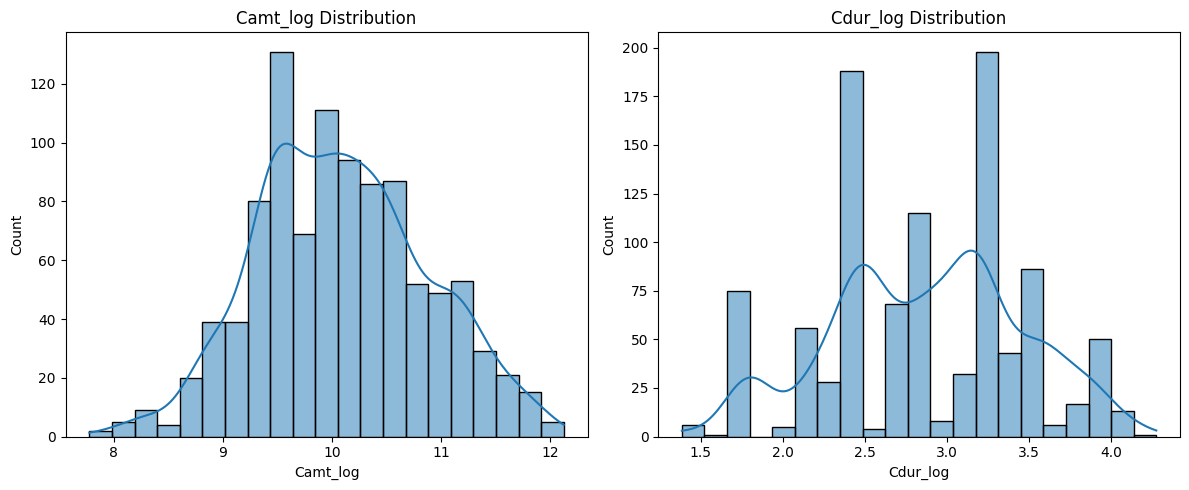

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['Camt_log'], kde=True, ax=axes[0])
axes[0].set_title('Camt_log Distribution')

sns.histplot(df['Cdur_log'], kde=True, ax=axes[1])
axes[1].set_title('Cdur_log Distribution')

plt.tight_layout()
plt.show()

## Bivariate Analysis: Categorical Features vs Target

**Bivariate analysis explores the relationship between two different variables, and multivariate analysis analyzes three or more variables simultaneously to understand complex patterns.**

**Our First Analysis is for Chist vs creditscore**

so now we're looking at the relationship between two variables, specifically each feature against the target.

This is where you start answering "does this feature actually seem to matter for predicting creditworthiness?"

In [ ]:
df['Chist'].value_counts()

Chist
all settled till now      618
dues not paid earlier     293
all settled                49
none taken/all settled     40
Name: count, dtype: int64

In [ ]:
pd.crosstab(df['Chist'], df['Credit Score'], normalize='index')

Credit Score,bad,good
Chist,,
all settled,0.571429,0.428571
all settled till now,0.318770,0.681230
dues not paid earlier,0.170648,0.829352
none taken/all settled,0.625000,0.375000


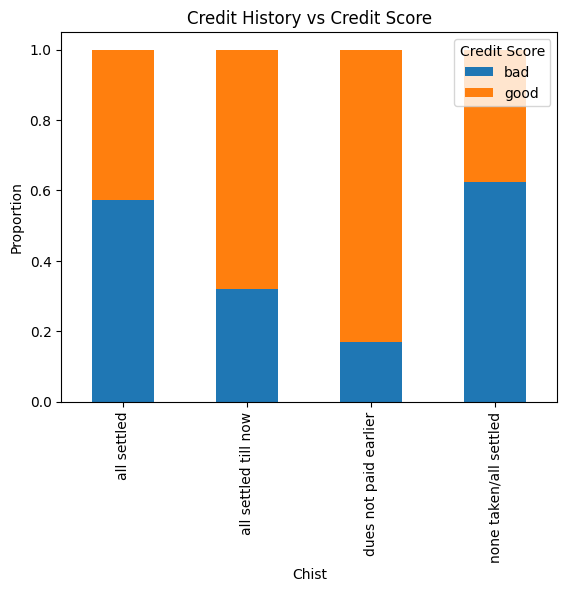

In [ ]:
import pandas as pd

pd.crosstab(df['Chist'], df['Credit Score'], normalize='index').plot(kind='bar', stacked=True) # normalize='index' converts raw counts into proportions within each Chist (Credit History) category — so you can directly compare "what % of each credit history group ended up good vs bad" regardless of how many people are in each group.
plt.title('Credit History vs Credit Score')
plt.ylabel('Proportion')
plt.show()

**The one-sentence takeaway: taller blue = more risky group, shorter blue = safer group. And the surprise is that the group whose label sounds riskiest ("dues not paid earlier") actually has the shortest blue bar — meaning it's the safest group in the data, not the riskiest.**

*What each bin means in the plot*

> - **`"all settled"` — this person had credit before and fully paid it all off, account closed.**

> - **`"all settled till now"` — this person has an active/ongoing credit line and has been paying it back properly so far (not finished yet, but no problems yet).**

> - **`"dues not paid earlier" `— this person missed or was late on payments in the past (some history of delinquency).**

> - **`"none taken/all settled"` — this is a bit of a catch-all: either they never took credit before, or everything was settled — basically a thin/limited credit history, hard to judge.**

##**Cpur (Purpose of loan) vs Credit Score**

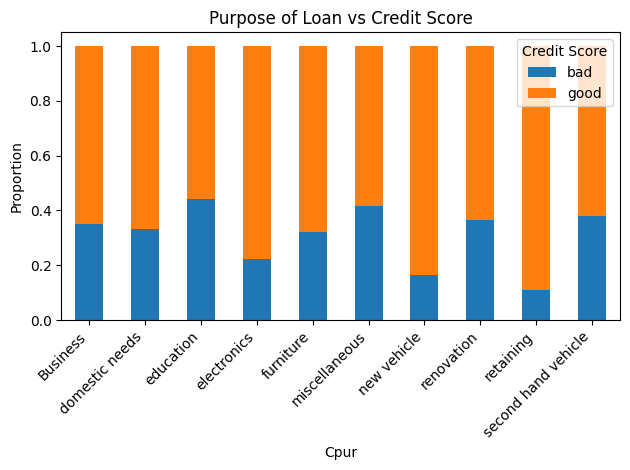

In [ ]:
pd.crosstab(df['Cpur'], df['Credit Score'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Purpose of Loan vs Credit Score')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Purpose of Loan vs Credit Score: `Cpur` shows meaningful variation in bad-credit rate across categories. "Education" has the highest bad-credit rate (43%), while "retraining" has the lowest (10%). This likely reflects the nature of collateral and income timing — vehicle/furniture loans are backed by tangible, resellable assets and are often taken by people with stable current income, while education loans are essentially bets on future (not current) earning potential, making them inherently riskier to underwrite.**

- Retraining — this is an investment tied to career/employability. Someone retraining is often already employed and actively improving their earning power — a decent risk signal.

- Education — this is a loan against future earning potential that doesn't exist yet. There's no physical asset to repossess, and the borrower may currently have little or no income (a student, or someone studying while not fully employed). The payoff is delayed and uncertain — you're betting on someone's future career, not their current financial position.

##**Prop (Property type) vs Credit Score**

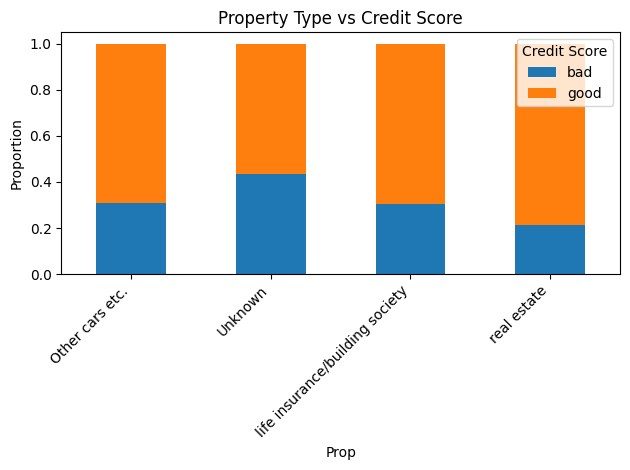

In [ ]:
pd.crosstab(df['Prop'], df['Credit Score'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Property Type vs Credit Score')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Property Type vs Credit Score: Prop shows real estate ownership associated with the lowest bad-credit rate (21%), consistent with property as both a wealth signal and loan collateral. "Unknown" property status has the highest bad-credit rate (43%) — likely reflecting that missing/undisclosed information correlates with risk, similar to the pattern seen in Chist.**

> - Real estate = owning property is a strong wealth/stability signal, and it's collateral the bank can fall back on. Lowest risk, makes sense.

> - Unknown = missing or undisclosed property info. This isn't necessarily that these people are inherently riskier — it's that the bank (and the model) has less information to judge them on, similar to the "none taken" pattern we saw with Chist. Uncertainty itself tends to correlate with risk in these datasets.

> - Life insurance/building society and Other cars etc. = these represent moderate assets, sitting reasonably in the middle — not as strong as owning real estate outright, but not nothing either.

##**Feature Engineering**

In [ ]:
display(f'Total columns => {df.columns.__len__()}')
display(f'Total Rows    =>  {df.index.__len__()}')

'Total columns => 23'

'Total Rows    =>  1000'

In [ ]:
df['InRate'].value_counts()

InRate
4    476
2    231
3    157
1    136
Name: count, dtype: int64

**The different activities that will happen in feature engineering**

1. Ordinal-style categoricals (`Cbal`, `Sbal` — balance ranges like "0 <= Rs. < 2000", "no checking account"): these have a natural order (no account < low balance < high balance), so they're candidates for ordinal encoding — map each category to a number that preserves that order (e.g., 0, 1, 2, 3).

2. Nominal categoricals (`Chist`, `Cpur`, `MSG`, `Oparties`, `Prop`, `Htype`, `JobType`, `telephone`, `foreign`): no natural order between categories (e.g., "education" isn't "more" or "less" than "furniture"). These need one-hot encoding — turn each category into its own 0/1 column — so the model doesn't assume a false ranking.

3. Numeric features already in good shape: `Camt_log`, `Cdur_log`, `age`, `InRate` (though we noted `InRate` looks more ordinal/discrete than continuous — worth a quick discussion), `NumCred`, `Ndepend`, `inPlans`.

4. Target: `CreditScore` (good/bad) needs to become binary 0/1 for most sklearn models to work with it directly.

In [ ]:
print(df['Cbal'].unique())
print(df['Sbal'].unique())

<ArrowStringArray>
['0 <= Rs. < 2000', 'no checking account', ' Rs. < 0', 'Rs. >=2000']
Length: 4, dtype: str
<ArrowStringArray>
[          'Rs. < 1000',   'no savings account',        'Rs. >= 10,000',
 '5000 <= Rs. < 10,000',  '1000 <= Rs. < 5,000']
Length: 5, dtype: str


In [ ]:
df['Cbal'] = df['Cbal'].str.strip()
df['Sbal'] = df['Sbal'].str.strip()

In [ ]:
df['Cbal']

0          0 <= Rs. < 2000
1          0 <= Rs. < 2000
2          0 <= Rs. < 2000
3          0 <= Rs. < 2000
4      no checking account
              ...         
995    no checking account
996        0 <= Rs. < 2000
997    no checking account
998             Rs. >=2000
999                Rs. < 0
Name: Cbal, Length: 1000, dtype: str

In [ ]:
# The reasoning: Given the category 'Rs. < 0' exists (negative balance), I'd argue the natural real-world order is: no account status disclosed < negative balance < low positive balance < high balance — because having negative account is a clearer negative signal than simply not having an account.

cbal_map = {
    'no checking account': 0,
    'Rs. < 0': 1,
    '0 <= Rs. < 2000': 2,
    'Rs. >=2000': 3
}

sbal_map = {
    'no savings account': 0,
    'Rs. < 1000': 1,
    '1000 <= Rs. < 5,000': 2,
    '5000 <= Rs. < 10,000': 3,
    'Rs. >= 10,000': 4
}

df['Cbal_encoded'] = df['Cbal'].map(cbal_map)
df['Sbal_encoded'] = df['Sbal'].map(sbal_map)

In [ ]:
df.head(3)

,Cbal,Cdur,Chist,Cpur,Camt,Sbal,Edur,InRate,MSG,Oparties,...,NumCred,JobType,Ndepend,telephone,foreign,Credit Score,Camt_log,Cdur_log,Cbal_encoded,Sbal_encoded
0,0 <= Rs. < 2000,9,all settled till now,Business,13790,Rs. < 1000,1 to 4 years,2,married or widowed male,no one,...,1,employee with official position,1,yes,no,good,9.531699,2.197225,2,1
1,0 <= Rs. < 2000,15,dues not paid earlier,electronics,15250,no savings account,more than 7 years,4,single male,"yes, guarantor",...,2,employee with official position,1,yes,no,good,9.632335,2.708050,2,0
2,0 <= Rs. < 2000,36,none taken/all settled,Business,19410,Rs. < 1000,more than 7 years,4,single male,no one,...,1,"employed either in management, self or in high...",1,yes,no,bad,9.873544,3.583519,2,1


In [ ]:
# Checking if the ordinal attributes were encoded safely without throwing any error

df[['Cbal', 'Cbal_encoded', 'Sbal', 'Sbal_encoded']].isnull().sum()

Cbal            0
Cbal_encoded    0
Sbal            0
Sbal_encoded    0
dtype: int64

##**One Hot Encoding**

In [ ]:
nominal_cols = ['Chist', 'Cpur', 'MSG', 'Oparties', 'Prop', 'Htype', 'JobType', 'telephone', 'foreign']

df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True) # The setting to discuss: drop_first. By default, pd.get_dummies() creates a column for every category. But if a feature has, say, 4 categories, knowing 3 of them tells you the 4th for free (if it's not A, B, or C, it must be D) — so keeping all 4 columns is redundant information. This redundancy causes a problem called multicollinearity, which specifically hurts models like Logistic Regression (it can distort coefficient interpretation and inflate variance), though tree-based models like Random Forest are mostly unaffected by it.

*If you notice, not all the columns the were encoded are present, due to a redundancy of information call Multicoliniearity*

**How you still get the missing category's info "for free", use Chist for example: if a row has 0 in all three remaining columns, it must mean the original value was "all settled" — because that's the only category left unaccounted for. So no information is lost, it's just implied rather than explicitly stored.**

In [ ]:
df_encoded.columns

Index(['Cbal', 'Cdur', 'Camt', 'Sbal', 'Edur', 'InRate', 'Rdur', 'age',
       'inPlans', 'NumCred', 'Ndepend', 'Credit Score', 'Camt_log', 'Cdur_log',
       'Cbal_encoded', 'Sbal_encoded', 'Chist_all settled till now',
       'Chist_dues not paid earlier', 'Chist_none taken/all settled',
       'Cpur_domestic needs', 'Cpur_education', 'Cpur_electronics',
       'Cpur_furniture', 'Cpur_miscellaneous', 'Cpur_new vehicle',
       'Cpur_renovation', 'Cpur_retaining', 'Cpur_second hand vehicle',
       'MSG_divorced or separated or married female',
       'MSG_married or widowed male', 'MSG_single male',
       'Oparties_yes, co-applicant', 'Oparties_yes, guarantor', 'Prop_Unknown',
       'Prop_life insurance/building society', 'Prop_real estate', 'Htype_own',
       'Htype_pays rent', 'JobType_employee with official position',
       'JobType_non resident either unemployed or  unskilled ',
       'JobType_resident unskilled', 'telephone_yes', 'foreign_yes'],
      dtype='str')

How the models usse patterns to depict which category that was not encoded to use.
---

The model just sees the 0/1 values as regular numeric input, same as any other feature. During training, it learns patterns like: "when `Chist_dues not paid earlier`, `Chist_none taken/all settled`, and `Chist_all settled till now` are all 0, that combination correlates with X outcome." It never needs to know that combination represents "all settled" — the pattern of all-zeros itself becomes a signal the model learns to associate with an outcome, just like any other feature combination. So the meaning is implicit in the pattern, not something the algorithm consciously infers.

In [ ]:
df_encoded['Credit Score'] = df_encoded['Credit Score'].map({'good': 0, 'bad': 1})

In [ ]:
df_encoded['Credit Score'].value_counts()

Credit Score
0    700
1    300
Name: count, dtype: int64

##**Dropping Columns that have been encoded already**

In [ ]:
df_final = df_encoded.drop(columns=['Cbal', 'Sbal', 'Camt', 'Cdur'])

In [ ]:
print(df_final['Edur'].unique())
print(df_final['Rdur'].unique())
print(df_final['inPlans'].unique())

<ArrowStringArray>
[     '1 to 4 years', 'more than 7 years',  'less than 1 year',
      '4 to 7 years',      'not employed']
Length: 5, dtype: str
<ArrowStringArray>
['less than a year', 'more than 3 years', '1 to 2 years', '2 to 3 years']
Length: 4, dtype: str
<ArrowStringArray>
['bank', 'none', 'stores']
Length: 3, dtype: str


In [ ]:
# Edur (employment duration) — clear natural order, including a tricky edge case: where does "not employed" sit? Logically, it represents less employment stability than any employed duration, so it belongs at the bottom:
edur_map = {
    'not employed': 0,
    'less than 1 year': 1,
    '1 to 4 years': 2,
    '4 to 7 years': 3,
    'more than 7 years': 4
}

In [ ]:
# Rdur (residence duration) — same logic, straightforward order:

rdur_map = {
    'less than a year': 1,
    '1 to 2 years': 2,
    '2 to 3 years': 3,
    'more than 3 years': 4
}

In [ ]:
# inPlans — no natural order between "bank," "none," "stores" (these are different types of installment plans, not a ranked scale), so this is nominal → one-hot encode, same as Chist/Cpur etc.

df_final['Edur'] = df_final['Edur'].str.strip()
df_final['Rdur'] = df_final['Rdur'].str.strip()

df_final['Edur_encoded'] = df_final['Edur'].map(edur_map)
df_final['Rdur_encoded'] = df_final['Rdur'].map(rdur_map)

df_final = pd.get_dummies(df_final, columns=['inPlans'], drop_first=True)

df_final = df_final.drop(columns=['Edur', 'Rdur'])

In [ ]:
df.duplicated().sum()

np.int64(0)

##**Data Splitting**

**Why split now, before anything else? If you scale or transform your entire dataset first and then split it, information from the test set "leaks" into how you calculated things like means/std for scaling — meaning your test set is no longer a true simulation of "unseen data." The model gets a subtle, unfair sneak peek. So the rule is: split first, then fit any transformers only on the training data.**

In [ ]:
X = df_final.drop(columns=['Credit Score'])
y = df_final['Credit Score']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(800, 39) (200, 39)
Credit Score
0    0.7
1    0.3
Name: proportion, dtype: float64
Credit Score
0    0.7
1    0.3
Name: proportion, dtype: float64


*scaling only makes sense for genuinely continuous numeric columns. Applying it to your one-hot (0/1) or ordinal-encoded columns doesn't break anything technically, but it's unnecessary and makes those columns harder to interpret later. So we'll scale selectively.*

In [ ]:
numeric_cols = ['age', 'Camt_log', 'Cdur_log', 'InRate', 'NumCred', 'Ndepend']

In [ ]:
# Why fit_transform on train but only transform on test — this is the same data-leakage principle from the split. fit calculates the mean/std used for scaling. If you let it see the test set while fitting, the test set influences the very transformation being applied to it — another sneak peek.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [ ]:
X_train_scaled[numeric_cols].describe()

,age,Camt_log,Cdur_log,InRate,NumCred,Ndepend
count,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02
mean,1.065814e-16,-3.419487e-16,2.797762e-16,-1.532108e-16,-1.065814e-16,-1.687539e-16
std,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00
min,-1.474634e+00,-2.884799e+00,-2.542016e+00,-1.764792e+00,-7.171027e-01,-4.262439e-01
25%,-7.664200e-01,-7.217305e-01,-6.683211e-01,-8.700937e-01,-7.171027e-01,-4.262439e-01
50%,-1.909964e-01,-4.810147e-02,2.320410e-02,2.460419e-02,-7.171027e-01,-4.262439e-01
75%,5.614807e-01,6.440572e-01,5.138490e-01,9.193021e-01,9.751750e-01,-4.262439e-01
max,3.482862e+00,2.570438e+00,2.387544e+00,9.193021e-01,4.359730e+00,2.346074e+00


In [ ]:
# The core reasoning why we didn't use average parameter: macro-average treats both classes as equally important by design — that's literally what it's built for (fair evaluation when you don't want the majority class to dominate the metric). But we explicitly decided earlier that the two classes are not equally important here — missing "bad" is 5x worse than misclassifying "good." So using macro-average would actually work against the cost-sensitive framing we agreed on at the start; it would quietly average away the exact risk we're trying to keep visible.

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

results_log = []  # stores every run so we can compare later

def train_and_evaluate(model, model_name, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1 ("bad")

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)  # this IS recall on "bad" since bad=1
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    cm = confusion_matrix(y_test, y_pred)

    print(f"--- {model_name} ---")
    print(f"Precision: {precision:.3f}")
    print(f"Recall (bad class): {recall:.3f}")
    print(f"F1-Score: {f1:.3f}")
    print(f"ROC-AUC: {roc_auc:.3f}")
    print(f"Confusion Matrix:\n{cm}")
    print()

    results_log.append({
        'model': model_name,
        'precision': precision,
        'recall_bad': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'false_negatives': cm[1][0]  # actual bad, predicted good — the costly error
    })

    return model

##**Model Selection**

1. **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)

log_reg_model = train_and_evaluate(
    model=log_reg,
    model_name='Logistic Regression (baseline)',
    X_train=X_train_scaled,
    y_train=y_train,
    X_test=X_test_scaled,
    y_test=y_test
)

--- Logistic Regression (baseline) ---
Precision: 0.449
Recall (bad class): 0.367
F1-Score: 0.404
ROC-AUC: 0.721
Confusion Matrix:
[[113  27]
 [ 38  22]]



- 113 = predicted good, actually good ✅ (true negative)
- 27 = predicted bad, actually good ❌ (false positive — rejected a good customer)
- 38 = predicted good, actually bad ❌ (false negative — the costly error, approved someone who's actually bad)
- 22 = predicted bad, actually bad ✅ (true positive — correctly caught)

> - Precision (0.449): of all applicants the model flagged as "bad," only 45% actually were.

> - Recall (0.367): of all genuinely "bad" applicants, the model correctly caught only 37%.

> - F1-Score (0.404): the balance between precision and recall — low here because both are low.

> - ROC-AUC (0.721): the model's overall ability to rank bad applicants as riskier than good ones — decent, but not being translated into good predictions at the default threshold.

##**2. Random Forest**

In [ ]:
# Note the switch: X_train/X_test here, not the _scaled versions — feeding Random Forest the scaled data wouldn't break it, but it's unnecessary, and using the raw version keeps things interpretable (e.g., if you look at feature importances later, they'll be in original units, not scaled units).

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf_model = train_and_evaluate(
    model=rf,
    model_name='Random Forest (baseline)',
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

--- Random Forest (baseline) ---
Precision: 0.605
Recall (bad class): 0.433
F1-Score: 0.505
ROC-AUC: 0.787
Confusion Matrix:
[[123  17]
 [ 34  26]]



- 123 true negatives (up from 113)
- 17 false positives (down from 27 — fewer good customers wrongly rejected)
- 34 false negatives (down from 38 — the costly error, slightly improved)
- 26 true positives (up from 22 — caught more actual bad cases)

##**3. XGBoost**

In [ ]:
# Since XGB is an ensemble algorithm like random forest, it is able to use the raw unscaled Split train set for training

from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')

xgb_model = train_and_evaluate(
    model=xgb,
    model_name='XGBoost (baseline)',
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

--- XGBoost (baseline) ---
Precision: 0.633
Recall (bad class): 0.517
F1-Score: 0.569
ROC-AUC: 0.776
Confusion Matrix:
[[122  18]
 [ 29  31]]



- 122 true negatives

- 18 false positives

- 29 false negatives (down from 34 for RF, 38 for LogReg — best so far)

- 31 true positives (up from 26 for RF, 22 for LogReg)

> **What's notable: XGBoost is the first model to cross the 50% recall mark on bad cases — meaning it now catches more than half of genuinely bad-credit applicants, versus Random Forest's 43% and Logistic Regression's 37%.**

##**4. SVC (Support Vector Classifier)**

In [ ]:
# probability=True required — by default, SVC doesn't compute probability estimates (it's only built to output class labels), so predict_proba() would throw an error inside our function. Setting probability=True tells sklearn to run an extra internal calibration step to enable probabilities — useful for us since we need them for ROC-AUC, but worth knowing it makes training slightly slower than default SVC.

from sklearn.svm import SVC

svc = SVC(random_state=42, probability=True)

svc_model = train_and_evaluate(
    model=svc,
    model_name='SVC (baseline)',
    X_train=X_train_scaled, # Scaling required — SVC is distance-based like Logistic Regression, so we're back to using X_train_scaled/X_test_scaled.
    y_train=y_train,
    X_test=X_test_scaled,
    y_test=y_test
)

--- SVC (baseline) ---
Precision: 0.727
Recall (bad class): 0.267
F1-Score: 0.390
ROC-AUC: 0.773
Confusion Matrix:
[[134   6]
 [ 44  16]]



##**Key Observations:**

> **XGBoost is the strongest all-round baseline — best F1 (0.569), best Recall on bad (0.517), fewest false negatives (29). It's the first model to catch more than half of actual bad-credit applicants.**

> **SVC is a cautionary example of exactly the problem we predicted. It has the highest Precision (0.727) but by far the worst Recall on bad (0.267) and the most false negatives (44) — worse than even the simplest model, Logistic Regression. This means SVC is very "cautious" about flagging someone as bad (rarely wrong when it does), but it misses the vast majority of actual bad cases (44 out of 60 slipped through). Given the 5x cost of a false negative, SVC's high precision is misleading — it looks good on paper (high precision) while quietly being the riskiest model in practice for this specific business problem.**

> **Random Forest sits solidly in the middle — meaningful improvement over Logistic Regression, but outperformed by XGBoost on every metric that matters for the bad class.**

*Across all four models, Recall on bad is consistently the weakest metric — ranging from 26.7% to 51.7%. This confirms the class-imbalance concern raised during EDA: default-trained models are systematically biased toward the majority "good" class, exactly the pattern predicted, and exactly why the cost-matrix framing matters.*

##**Class-Weight Optimization**

Quick concept refresher: class_weight='balanced' tells the model to automatically penalize mistakes on the minority class ("bad") more heavily during training, roughly inversely proportional to how frequent that class is. Since "bad" is 30% of the data, the model effectively treats each bad-class error as more "expensive" during learning — pushing the model to work harder not to miss them. It's not the exact 5x from the cost matrix, but it's the standard, built-in way to fight imbalance-driven bias.

##**Logistic Regression**

In [ ]:
log_reg_weighted = LogisticRegression(random_state=42, class_weight='balanced')

log_reg_weighted_model = train_and_evaluate(
    model=log_reg_weighted,
    model_name='Logistic Regression (class-weighted)',
    X_train=X_train_scaled,
    y_train=y_train,
    X_test=X_test_scaled,
    y_test=y_test
)

--- Logistic Regression (class-weighted) ---
Precision: 0.436
Recall (bad class): 0.683
F1-Score: 0.532
ROC-AUC: 0.727
Confusion Matrix:
[[87 53]
 [19 41]]



|| 	Baseline LogReg | Weighted LogReg |
|---|---|---
| True Negatives | 113 | 87 |
| False Positives | 27 | 53 |
| False Negatives | 38 | 19 |
| True Positives | 22 | 41 |

##**Random Forest**

In [ ]:
rf_weighted = RandomForestClassifier(random_state=42, class_weight='balanced')

rf_weighted_model = train_and_evaluate(
    model=rf_weighted,
    model_name='Random Forest (class-weighted)',
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

--- Random Forest (class-weighted) ---
Precision: 0.581
Recall (bad class): 0.300
F1-Score: 0.396
ROC-AUC: 0.791
Confusion Matrix:
[[127  13]
 [ 42  18]]



Recall actually got worse (0.433 → 0.300), and false negatives increased (34 → 42). This is the opposite of what happened with Logistic Regression, and opposite of what we'd naively expect from "balancing" the classes.

class_weight interacts differently with Random Forest's internal mechanics than with Logistic Regression. Logistic Regression directly weights the loss function during a single optimization pass — it's a clean, direct penalty. Random Forest is an ensemble of many decision trees, each trained on a bootstrapped (randomly resampled) subset of the data. Class weighting in RF influences the split criteria within each tree (which feature/threshold reduces weighted impurity most), not a single global loss — so the effect is less direct and can behave unpredictably depending on how the random bootstrapping happens to interact with the weighting.

##**XGBoost**

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

xgb_weighted = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight)

xgb_weighted_model = train_and_evaluate(
    model=xgb_weighted,
    model_name='XGBoost (class-weighted)',
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

2.3333333333333335
--- XGBoost (class-weighted) ---
Precision: 0.525
Recall (bad class): 0.533
F1-Score: 0.529
ROC-AUC: 0.762
Confusion Matrix:
[[111  29]
 [ 28  32]]



Interesting — even though recall went up slightly, the cost actually got marginally worse (163 → 169), because the small recall gain (1 fewer false negative) wasn't enough to offset the jump in false positives (18 → 29, an increase of 11). This is a good concrete illustration of why we're tracking the cost formula rather than just eyeballing recall alone — a metric can look like it improved (recall did tick up) while the overall business cost quietly got worse.

##**SVC**

In [ ]:
svc_weighted = SVC(random_state=42, probability=True, class_weight='balanced')

svc_weighted_model = train_and_evaluate(
    model=svc_weighted,
    model_name='SVC (class-weighted)',
    X_train=X_train_scaled,
    y_train=y_train,
    X_test=X_test_scaled,
    y_test=y_test
)

--- SVC (class-weighted) ---
Precision: 0.433
Recall (bad class): 0.750
F1-Score: 0.549
ROC-AUC: 0.753
Confusion Matrix:
[[81 59]
 [15 45]]



Recall jumped from 0.267 → 0.750 — the largest recall improvement of any model in this whole project. The weighted SVC now catches 45 out of 60 actual bad applicants, versus only 16 in the baseline. False negatives dropped from 44 all the way down to 15.

| Model | Precision | Recall | F1-Score | FN (FalseNegative) | | Cost |
|---|---|---|---|---|---|---
| Logistic Reg(base) | 0.449 | 0.367 | 0.404 | 38 |  | 217|
| LogReg(Weighted) | 	0.436 | 	0.683 | 0.532 | 	19 | | 148|
| RF (base) | 	0.605 | 	0.433 | 0.505 | 	34 | | 187|
| RF (weighted) | 0.581 | 	0.300 | 0.396 | 42 | | 	223|
| XGBoost (base) | 	0.633 | 0.517 | 0.569 | 29 | | 163|
| XGBoost (weighted) | 0.525 | 0.533 | 0.529 | 28 | | 169|
| SVC (base) | 0.727 | 0.267 | 0.390 | 44 | | 226|
|SVC (weighted)| 	0.433 | 0.750 | 0.549 |	15 | | 134|



**By total cost, SVC (weighted) is your best-performing model overall (134) — followed by LogReg (weighted) at 148, then XGBoost (base) at 163.**

Best Model: SVC (class-weighted)

By the cost-weighted metric defined at the start of this project (5× penalty for missing a bad applicant, 1× penalty for wrongly rejecting a good one), SVC with class_weight='balanced' is the best-performing model, at a total cost of 134 — the lowest of all eight runs, and a 41% cost reduction from its own baseline (226).

Key Findings
Class weighting is not universally beneficial — it substantially helped Logistic Regression (cost 217→148) and SVC (226→134), had a marginal/mixed effect on XGBoost (163→169), and actually hurt Random Forest (187→223). This shows the technique's effectiveness depends on how each algorithm internally uses the weighting — a direct loss-function penalty (Logistic Regression, SVC) responded very differently than an ensemble of trees with impurity-based splits (Random Forest).
Standard accuracy-oriented metrics can be misleading for this problem. SVC's baseline had the highest Precision (0.727) of all eight models, but was simultaneously the worst model in practice — missing 44 of 60 actual bad-credit applicants. This directly validates the decision, made at the start of this project, to track recall on the bad class and a cost-weighted score rather than relying on Precision/F1/Accuracy alone.
Optimizing for the wrong metric would have picked the wrong model. If model selection were based purely on F1-Score, XGBoost (baseline, F1=0.569) would look best. Under the cost matrix that actually reflects business risk, SVC (weighted) is the stronger choice despite a lower F1 (0.549) — a concrete demonstration of why metric selection should be driven by the real-world cost of errors, not by whichever number is highest by default.
The imbalance identified in EDA (700 good / 300 bad) directly explains the pattern seen across all baseline models — every baseline model showed noticeably weaker recall on the bad class than on the good class, consistent with the "accuracy paradox" flagged early in this project.
Recommendation

SVC (class-weighted) is recommended as the final model for this task, given the lowest total cost under the business-relevant cost matrix. Note the trade-off explicitly: this model rejects a meaningfully larger number of genuinely good applicants (59 false positives vs. 6 in the baseline) in exchange for catching far more actual bad-credit risks. Whether this trade-off is acceptable in a real deployment would depend on how the business weighs "lost good customers" against "loan defaults" — worth stating as a limitation/assumption rather than an absolute conclusion, since the 5:1 cost ratio used here is illustrative, not something the CodeAlpha brief specified explicitly.